/var/folders/y_/7smt58yn1_j1z08l67wqfxph0000gn/T/ipykernel_36015/947775825.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=3.0)


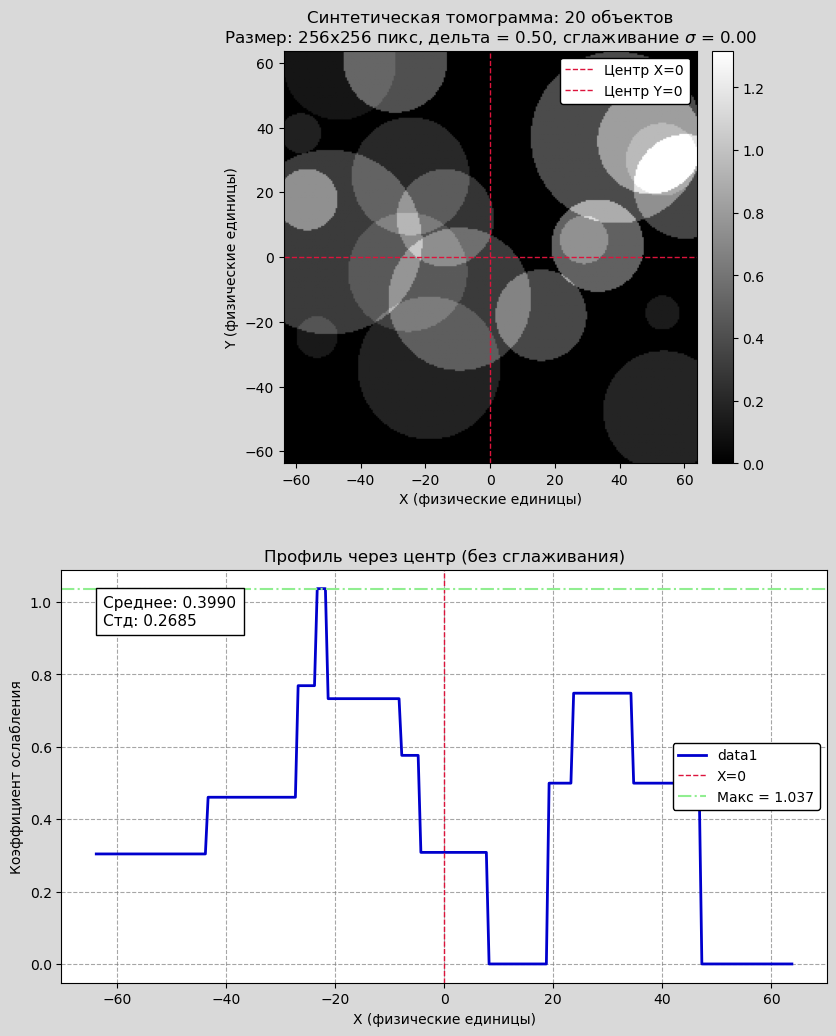

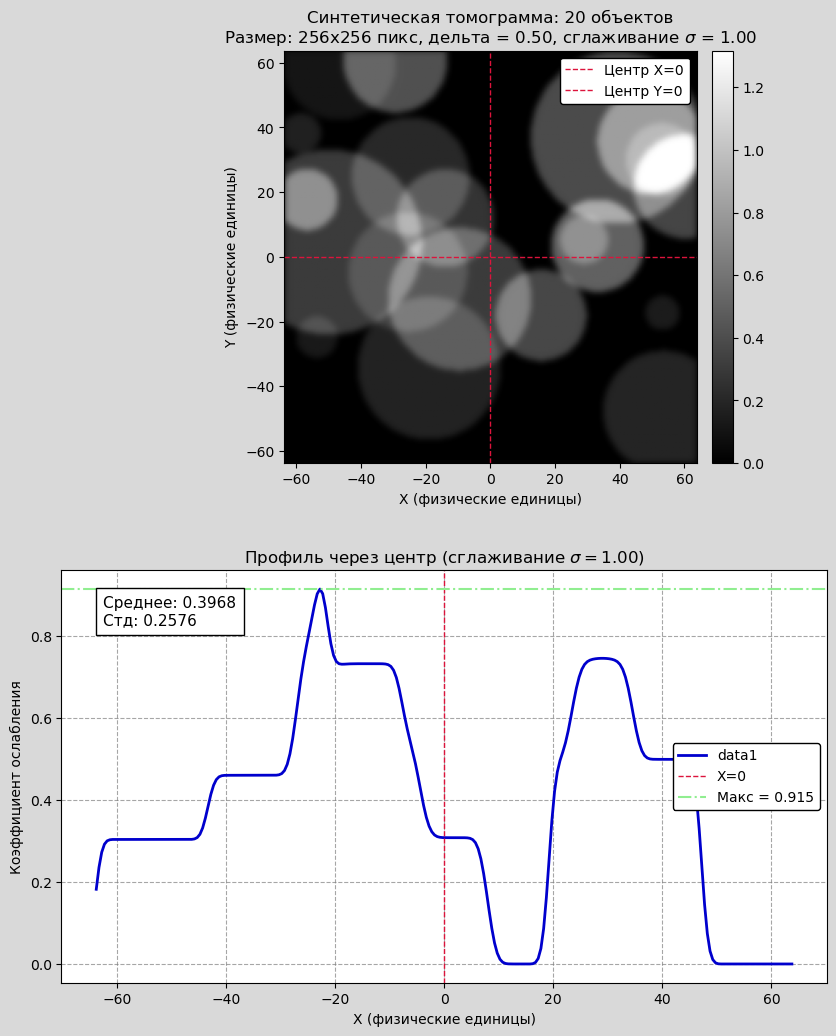

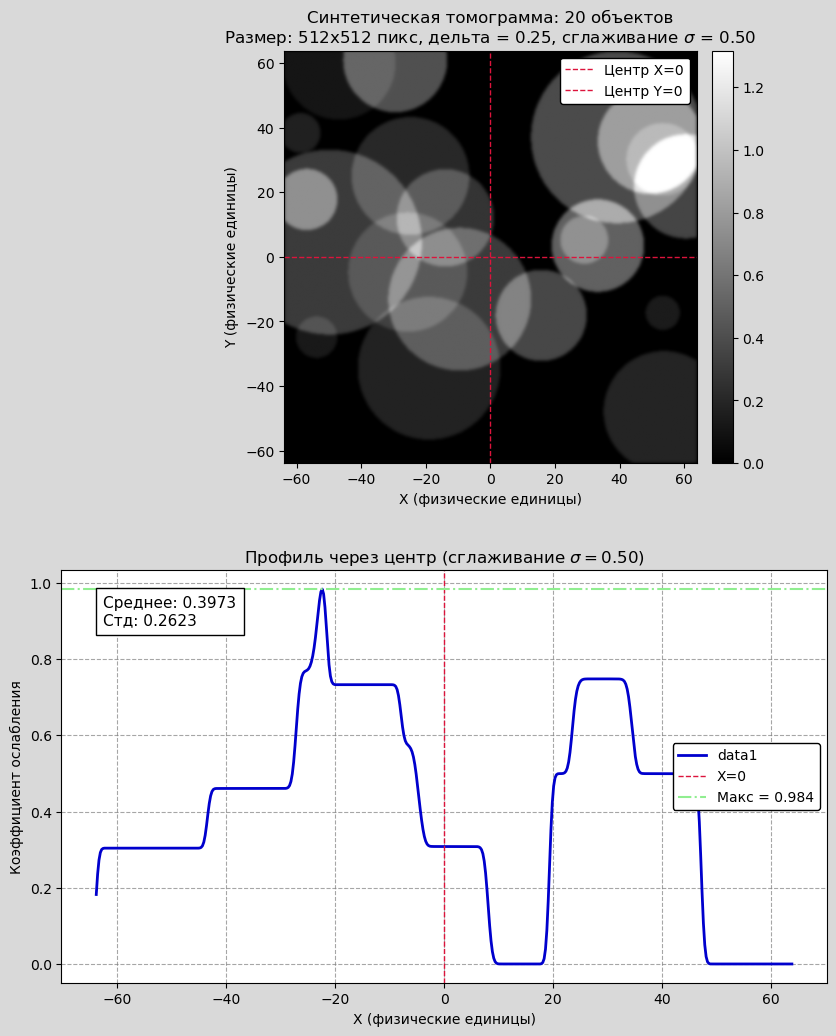

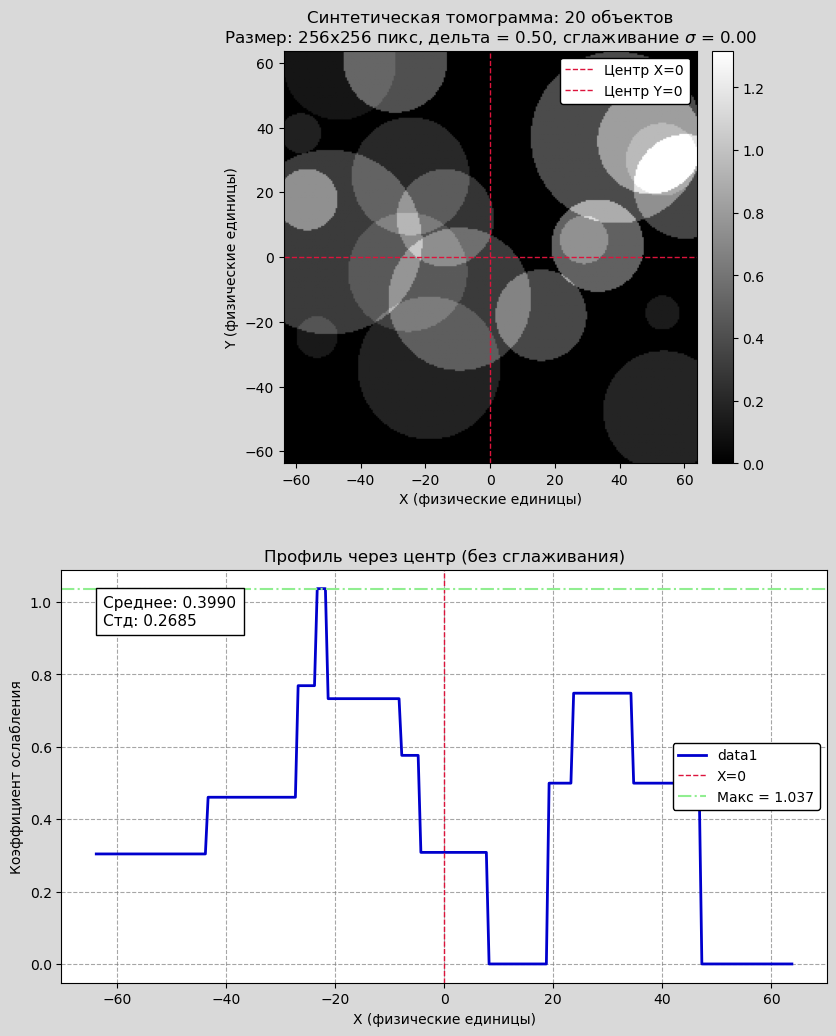

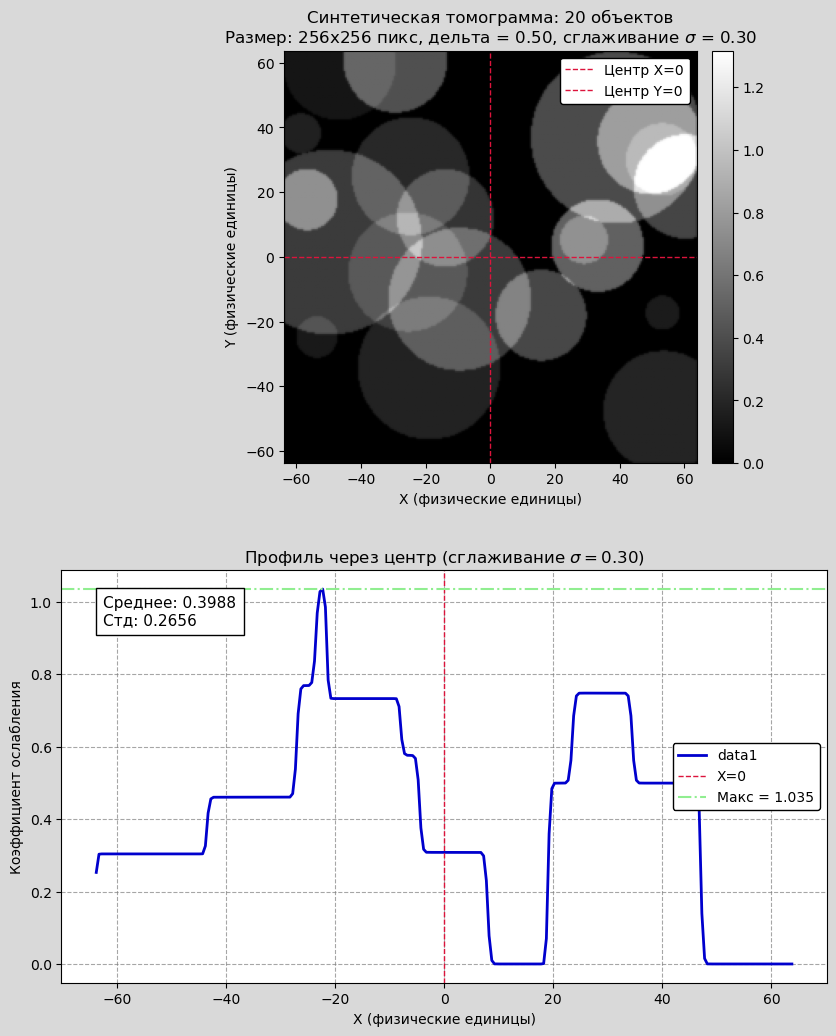

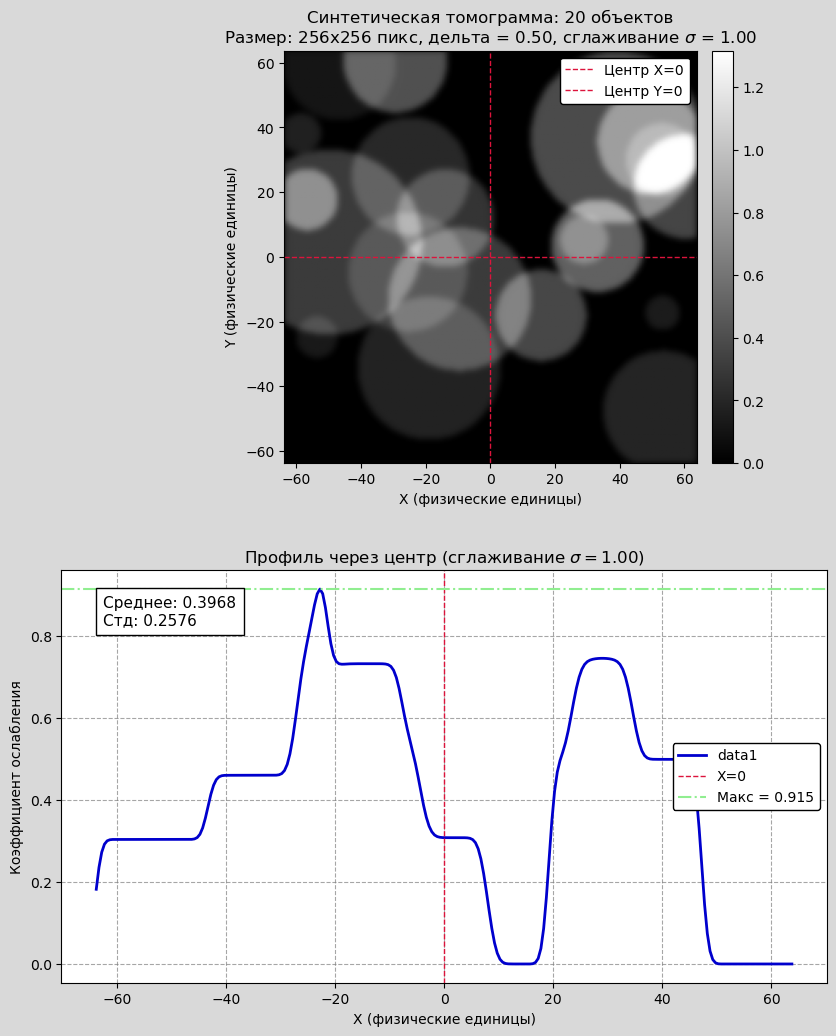

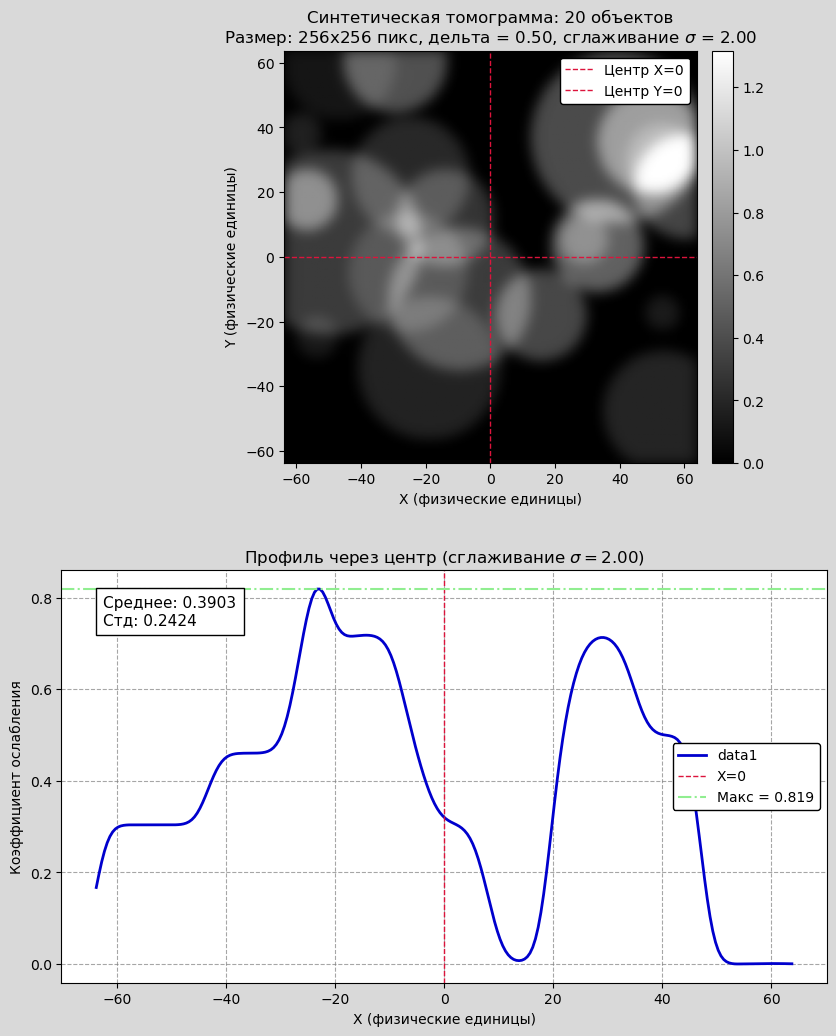

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve1d

class TomographyPhantom:
    """Класс для генерации и обработки синтетических томограмм."""
    
    def __init__(self, rows, cols, pixel_size):
        self.rows = rows
        self.cols = cols
        self.pixel_size = pixel_size
        
        # Векторизованное создание симметричной координатной сетки
        j = np.arange(1, cols + 1)
        i = np.arange(1, rows + 1)
        self.x_coords = (j - (cols + 1) / 2) * pixel_size
        self.y_coords = ((rows + 1) / 2 - i) * pixel_size
        self.X, self.Y = np.meshgrid(self.x_coords, self.y_coords)
        
        self.image = np.zeros((rows, cols))

    def generate_circles(self, num_circles, mu_bounds, r_bounds):
        """Добавление круглых объектов со случайными параметрами."""
        np.random.seed(15) # Фиксируем seed для повторяемости картинки
        
        for _ in range(num_circles):
            mu = np.random.uniform(mu_bounds[0], mu_bounds[1])
            r = np.random.uniform(r_bounds[0], r_bounds[1])
            center_x = np.random.uniform(self.x_coords.min(), self.x_coords.max())
            center_y = np.random.uniform(self.y_coords.min(), self.y_coords.max())
            
            # Логическая маска попадания координат внутрь радиуса
            distances_sq = (self.X - center_x)**2 + (self.Y - center_y)**2
            self.image[distances_sq <= r**2] += mu

    def apply_gaussian_filter(self, sigma):
        """Разделимая гауссова фильтрация."""
        if sigma <= 0:
            return
        
        # Формирование одномерного ядра
        radius = int(np.ceil(3 * sigma / self.pixel_size))
        p = np.arange(-radius, radius + 1)
        kernel = np.exp(-(p * self.pixel_size)**2 / (2 * sigma**2))
        kernel /= np.sum(kernel)
        
        # Последовательная свертка (быстрее, чем 2D свертка)
        self.image = convolve1d(self.image, kernel, axis=1, mode='constant', cval=0.0)
        self.image = convolve1d(self.image, kernel, axis=0, mode='constant', cval=0.0)

    def visualize(self, sigma, num_circles):
        """Отрисовка результатов с форматированием под заданные примеры."""
        fig = plt.figure(figsize=(9, 11), facecolor='#d9d9d9')
        
        # --- 1. Томограмма ---
        ax1 = fig.add_subplot(2, 1, 1)
        im = ax1.imshow(self.image, extent=[self.x_coords.min(), self.x_coords.max(), 
                                            self.y_coords.min(), self.y_coords.max()], 
                        origin='lower', cmap='gray')
        
        ax1.axvline(0, color='crimson', linestyle='--', linewidth=1, label='Центр X=0')
        ax1.axhline(0, color='crimson', linestyle='--', linewidth=1, label='Центр Y=0')
        ax1.legend(loc='upper right', framealpha=1, edgecolor='black')
        
        ax1.set_xlabel('X (физические единицы)')
        ax1.set_ylabel('Y (физические единицы)')
        
        ax1.set_title(f'Синтетическая томограмма: {num_circles} объектов\n'
                      f'Размер: {self.rows}x{self.cols} пикс, дельта = {self.pixel_size:.2f}, сглаживание $\sigma$ = {sigma:.2f}')
        
        cbar = fig.colorbar(im, ax=ax1, pad=0.02)
        
        # --- 2. Профиль ---
        ax2 = fig.add_subplot(2, 1, 2)
        mid_idx = self.rows // 2
        profile = self.image[mid_idx, :]
        
        ax2.plot(self.x_coords, profile, color='mediumblue', linewidth=2, label='data1')
        ax2.axvline(0, color='crimson', linestyle='--', linewidth=1, label='X=0')
        ax2.axhline(profile.max(), color='lightgreen', linestyle='-.', linewidth=1.5, label=f'Макс = {profile.max():.3f}')
        
        ax2.grid(True, linestyle='--', color='gray', alpha=0.7)
        ax2.set_xlabel('X (физические единицы)')
        ax2.set_ylabel('Коэффициент ослабления')
        
        prof_title = f"(сглаживание $\sigma = {sigma:.2f}$)" if sigma > 0 else "(без сглаживания)"
        ax2.set_title(f'Профиль через центр {prof_title}')
        
        # Вывод статистики
        stats_text = f"Среднее: {profile.mean():.4f}\nСтд: {profile.std():.4f}"
        
        # Создаем невидимые оси для абсолютного позиционирования текста (как в MATLAB)
        ax_text = fig.add_axes([0.15, 0.4, 0.2, 0.05])
        ax_text.axis('off')
        ax_text.text(0, 0, stats_text, fontsize=11, verticalalignment='bottom', 
                     bbox=dict(boxstyle='square,pad=0.5', facecolor='white', edgecolor='black'))
        
        ax2.legend(loc='center right', framealpha=1, edgecolor='black')
        ax2.set_facecolor('white')
        
        plt.tight_layout(pad=3.0)
        plt.show()

# --- Выполнение экспериментов ---
K = 20
mu_range = [0.1, 0.5]
R_range = [5, 30]

experiments = [
    {'M': 256, 'delta': 0.5, 'sigma': 0},
    {'M': 256, 'delta': 0.5, 'sigma': 1.0},
    {'M': 512, 'delta': 0.25, 'sigma': 0.5}
]

for exp in experiments:
    # Инициализируем квадратную матрицу M x M
    phantom = TomographyPhantom(exp['M'], exp['M'], exp['delta'])
    phantom.generate_circles(K, mu_range, R_range)
    phantom.apply_gaussian_filter(exp['sigma'])
    phantom.visualize(exp['sigma'], K)
# --- Исследование влияния параметра сглаживания ---
sigmas_to_test = [0, 0.3, 1.0, 2.0]

for sig in sigmas_to_test:
    # Используем базовые параметры: M=256, delta=0.5
    phantom_exp = TomographyPhantom(256, 256, 0.5)
    phantom_exp.generate_circles(K, mu_range, R_range)
    phantom_exp.apply_gaussian_filter(sig)
    phantom_exp.visualize(sig, K)

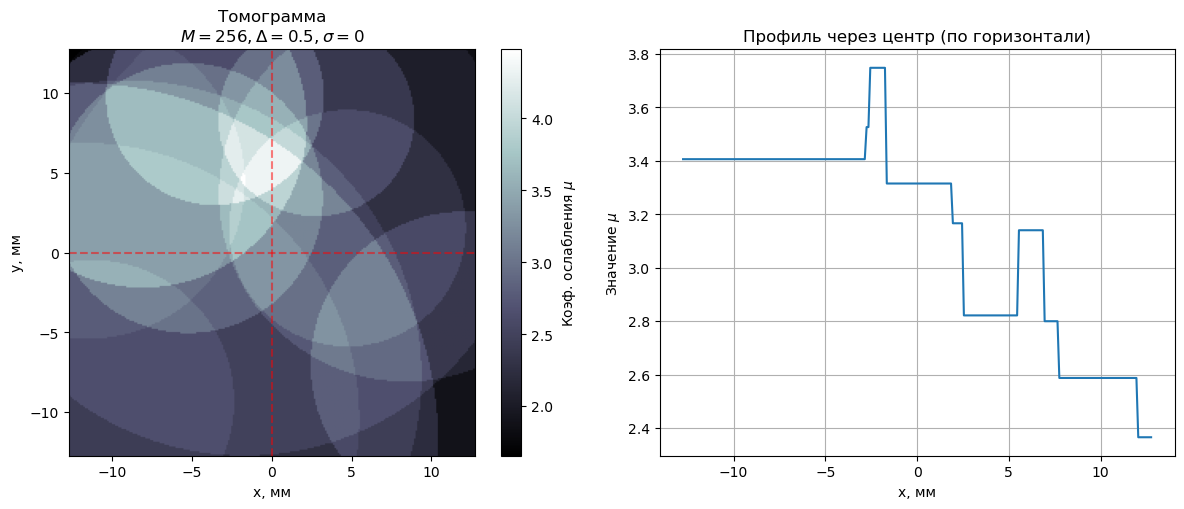

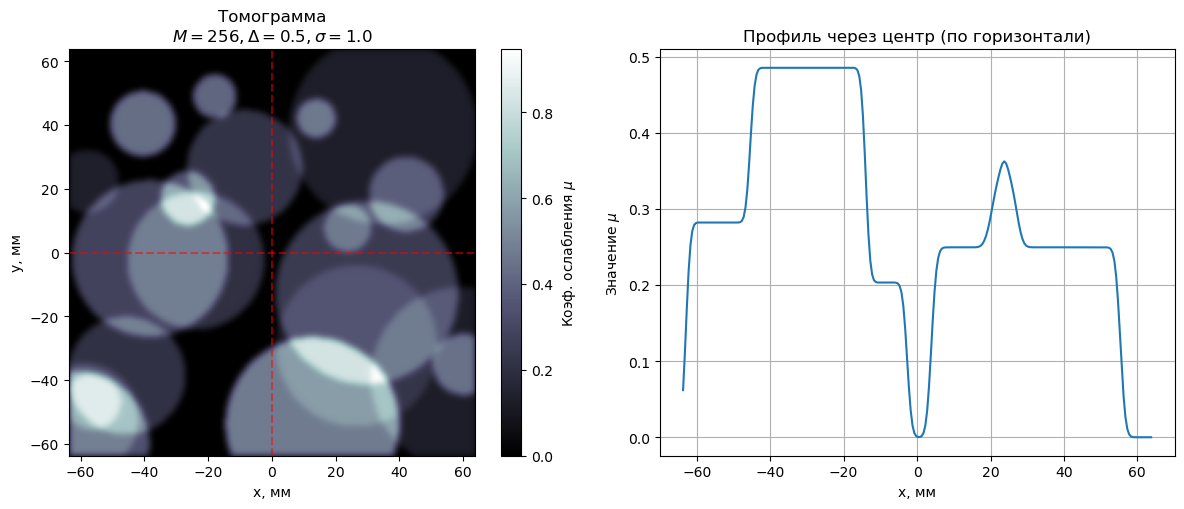

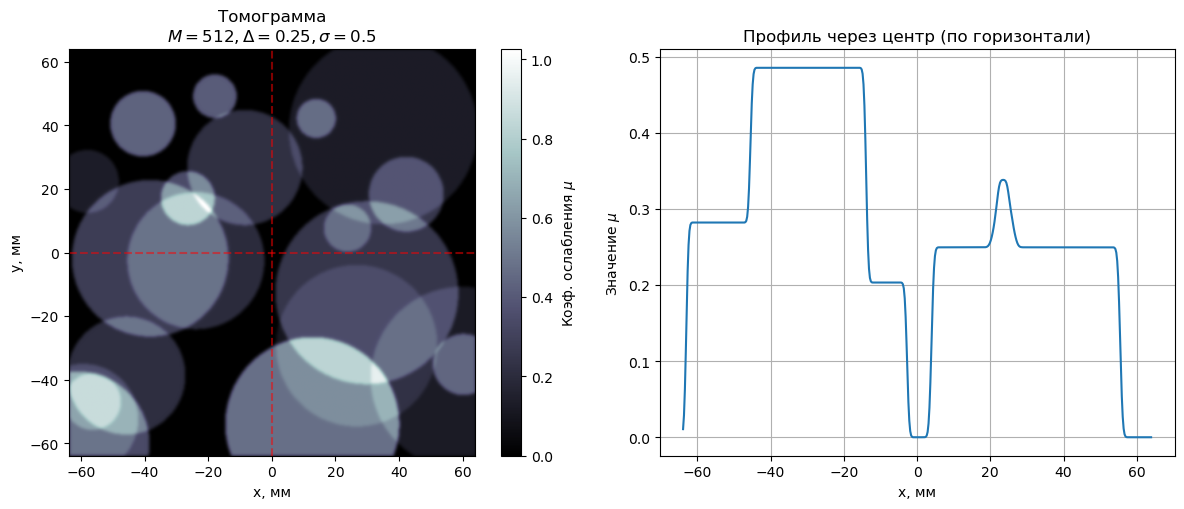

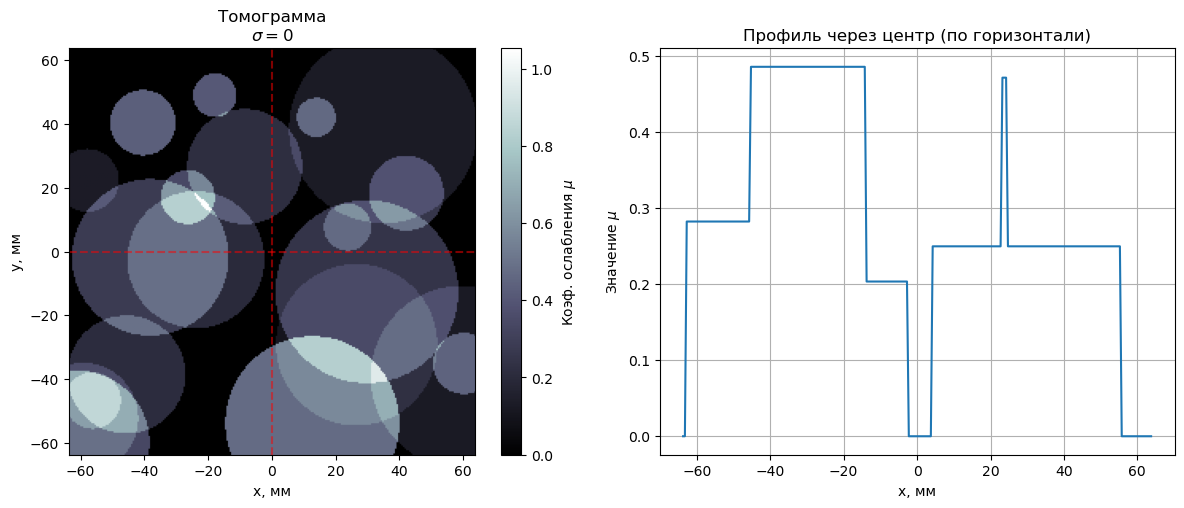

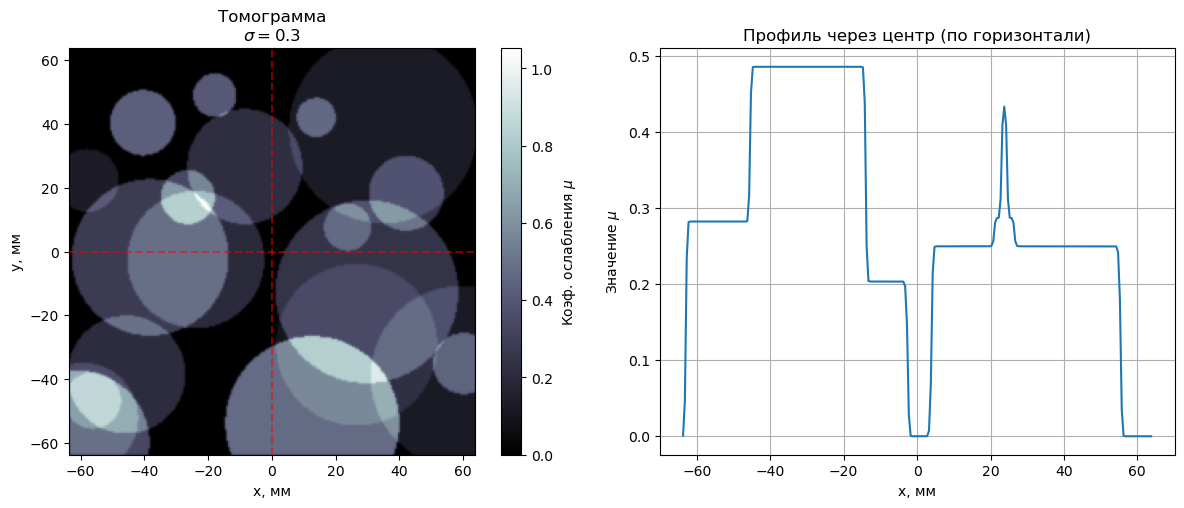

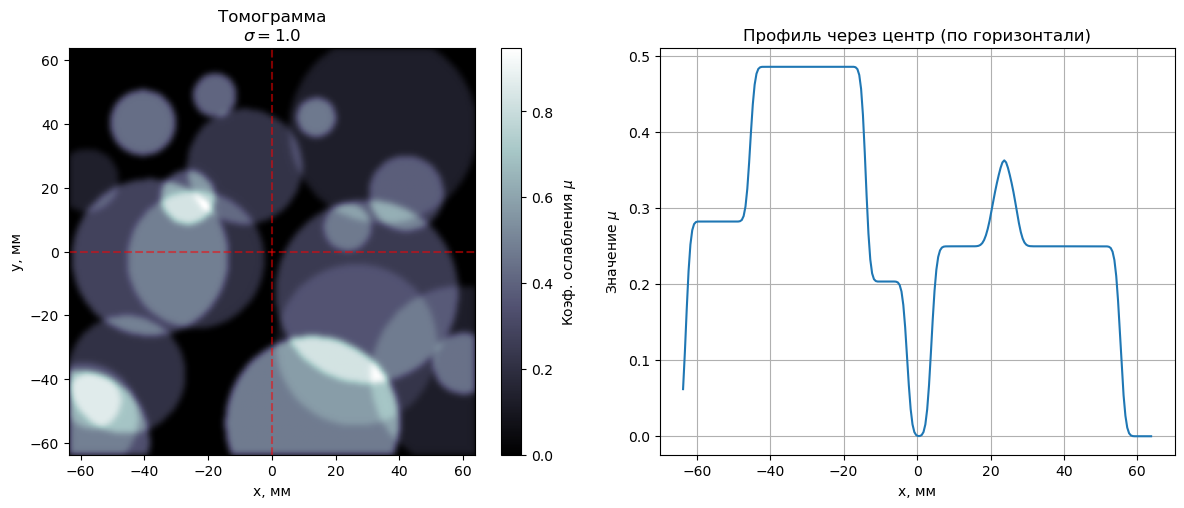

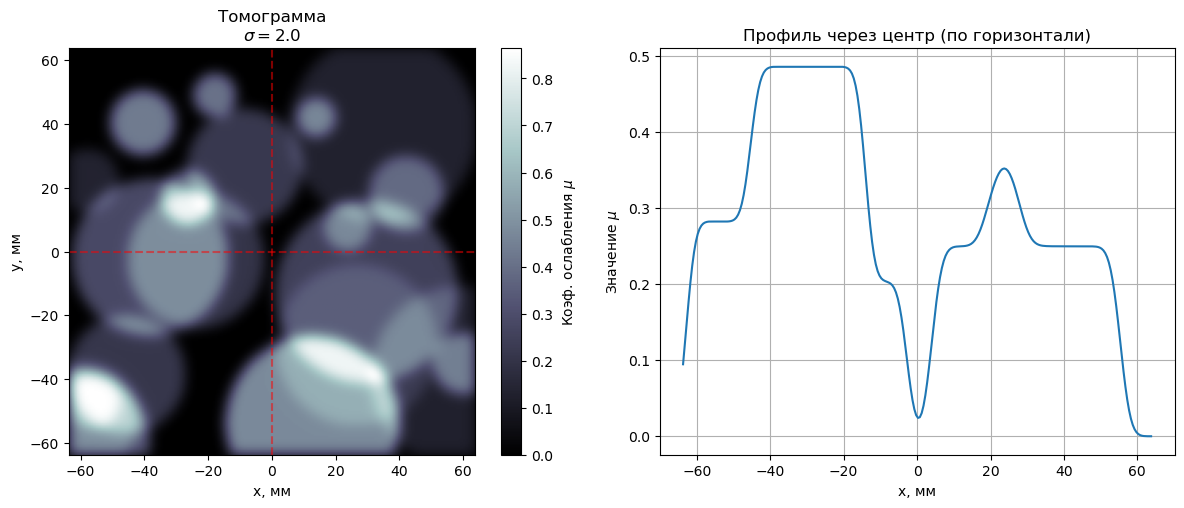

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def generate_phantom(M, N, delta, K, mu_range, R_range, sigma):
    # Шаг 1: Создание координатной сетки
    j_idx = np.arange(1, N + 1)
    i_idx = np.arange(1, M + 1)
    x = (j_idx - (N + 1) / 2) * delta
    y = ((M + 1) / 2 - i_idx) * delta
    X, Y = np.meshgrid(x, y)
    
    # Шаг 2: Инициализация томограммы
    P = np.zeros((M, N))
    
    np.random.seed(42) # Для воспроизводимости
    
    # Шаг 3: Добавление окружностей
    for k in range(K):
        mu_k = np.random.uniform(mu_range[0], mu_range[1])
        R_k = np.random.uniform(R_range[0], R_range[1])
        x_k = (np.random.rand() - 0.5) * N * delta
        y_k = (np.random.rand() - 0.5) * M * delta
        
        d_sq = (X - x_k)**2 + (Y - y_k)**2
        mask = (d_sq <= R_k**2).astype(float)
        P += mu_k * mask
        
    # Шаг 4: Сглаживание (если sigma > 0)
    if sigma > 0:
        L = int(np.ceil(3 * sigma / delta))
        p = np.arange(-L, L + 1)
        h = np.exp(-(p * delta)**2 / (2 * sigma**2)) / (np.sqrt(2 * np.pi) * sigma)
        h /= np.sum(h) # Нормировка
        
        P_temp = np.zeros_like(P)
        P_smooth = np.zeros_like(P)
        
        # Свертка по строкам (с дополнением нулями)
        for i in range(M):
            for j in range(N):
                val = 0
                for p_idx, p_val in enumerate(p):
                    col = j + p_val
                    if 0 <= col < N:
                        val += P[i, col] * h[p_idx]
                P_temp[i, j] = val
                
        # Свертка по столбцам
        for i in range(M):
            for j in range(N):
                val = 0
                for q_idx, q_val in enumerate(p):
                    row = i + q_val
                    if 0 <= row < M:
                        val += P_temp[row, j] * h[q_idx]
                P_smooth[i, j] = val
        P = P_smooth
        
    return P, X, Y

def plot_results(P, X, Y, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Томограмма
    im = ax1.imshow(P, extent=[X.min(), X.max(), Y.min(), Y.max()], origin='lower', cmap='bone')
    ax1.axhline(0, color='r', linestyle='--', alpha=0.5)
    ax1.axvline(0, color='r', linestyle='--', alpha=0.5)
    ax1.set_title(f'Томограмма\n{title}')
    ax1.set_xlabel('x, мм')
    ax1.set_ylabel('y, мм')
    # ИСПРАВЛЕНА СЛЕДУЮЩАЯ СТРОКА: ax1=ax1 заменено на ax=ax1
    fig.colorbar(im, ax=ax1, label='Коэф. ослабления $\mu$') 
    
    # Профиль по центру
    mid_row = P.shape[0] // 2
    ax2.plot(X[mid_row, :], P[mid_row, :])
    ax2.set_title('Профиль через центр (по горизонтали)')
    ax2.set_xlabel('x, мм')
    ax2.set_ylabel('Значение $\mu$')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# --- Эксперименты по заданию 4.1 ---
mu_range = [0.1, 0.5]
R_range = [5, 30]
K = 20

# Эксперимент 1
P1, X1, Y1 = generate_phantom(256, 256, 0.1, K, mu_range, R_range, 0)
plot_results(P1, X1, Y1, r'$M=256, \Delta=0.5, \sigma=0$')

# Эксперимент 2
P2, X2, Y2 = generate_phantom(256, 256, 0.5, K, mu_range, R_range, 1.0)
plot_results(P2, X2, Y2, r'$M=256, \Delta=0.5, \sigma=1.0$')

# Эксперимент 3
P3, X3, Y3 = generate_phantom(512, 512, 0.25, K, mu_range, R_range, 0.5)
plot_results(P3, X3, Y3, r'$M=512, \Delta=0.25, \sigma=0.5$')

# Исследование влияния параметра сглаживания (sigma = 0, 0.3, 1.0, 2.0)
for sig in [0, 0.3, 1.0, 2.0]:
    P_exp, X_exp, Y_exp = generate_phantom(256, 256, 0.5, K, mu_range, R_range, sig)
    plot_results(P_exp, X_exp, Y_exp, f'$\sigma={sig}$')